# **Latin Morphological Analyser** - Training

This notebook loads the processed datasets, defines the multi-head model, and runs the two-phase training: Phase 1 (frozen BERT, heads only) and Phase 2 (full fine-tune). The trained model is saved to Drive and pushed to the Hub.

## **Set Up Environment**

In [53]:
import os

### Install Latin BERT

Download the pre-trained Latin BERT model from the GitHub repository and define the path for the model to be used for fine-tuning.

In [54]:
# clone latin bert repo
!git clone https://github.com/dbamman/latin-bert.git
%cd latin-bert

fatal: destination path 'latin-bert' already exists and is not an empty directory.
/content/latin-bert


In [55]:
# Download pre-trained BERT model for Latin
!./scripts/download.sh

--2026-05-01 22:38:56--  https://drive.usercontent.google.com/download?export=download&id=1Te_14UB-DZ8wYPhHGyDg7LadDTjNzpti&confirm=t&uuid=e028b073-fba8-4720-93dd-e22d6147a11c
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.141.132, 2607:f8b0:4023:c0b::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.141.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 448020480 (427M) [application/octet-stream]
Saving to: ‘latin_bert.tar’

latin_bert.tar      100%[===================>] 427.27M  24.7MB/s    in 18s     

2026-05-01 22:39:15 (23.7 MB/s) - ‘latin_bert.tar’ saved [448020480/448020480]



In [56]:
!ls -lah models/latin_bert | head

total 428M
drwxrwxr-x 2 1001 1001 4.0K Sep  4  2020 .
drwxr-xr-x 4 root root 4.0K May  1 22:39 ..
-rw-rw-r-- 1 1001 1001  503 Sep  4  2020 config.json
-rw-rw-r-- 1 1001 1001 428M Sep  4  2020 pytorch_model.bin
-rw-rw-r-- 1 1001 1001 217K Sep  4  2020 vocab.txt


In [57]:
%cd ..

/content


In [58]:
MODEL_PATH = os.path.join("latin-bert", "models", "latin_bert")

### Import Dependencies

1. Import all required libraries.
2. Mount Google Drive for storage access.
3. Setup HuggingFace access through token.
4. Define available device to be used.
5. Import shared definitions.

In [59]:
import sys
import json
import torch
import numpy as np
import transformers
from transformers import AutoTokenizer, TrainingArguments, Trainer
import datasets
from datasets import load_from_disk
import sklearn
from sklearn.metrics import classification_report
import matplotlib
import matplotlib.pyplot as plt

In [60]:
%matplotlib inline

In [61]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get('HF_TOKEN'))

In [63]:
print(torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

True
Using device: cuda


In [64]:
# Import shared definitions (constants, dataclasses, model classes, data collator)
sys.path.append('/content/drive/MyDrive/FYP')
from morph_constants import FEATURE_ORDER, POS_FEATURE_MASK, ALL_FEATS, IGNORE_INDEX
from morphological_analyser import LatinMorphologicalAnalyserConfig, LatinMorphologicalAnalyser, MultiLabelDataCollator

In [65]:
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("scikit-learn:", sklearn.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")

Python: 3.12.13
PyTorch: 2.10.0+cu128
Transformers: 5.0.0
Datasets: 4.0.0
scikit-learn: 1.6.1
NumPy: 2.0.2
Matplotlib: 3.10.0
CUDA: 12.8
GPU: Tesla T4


## **Load Processed Data**

In [66]:
# Load tokenized datasets and label vocabularies
PROCESSED_DIR = "/content/drive/MyDrive/FYP/processed"

train_ds = load_from_disk(f"{PROCESSED_DIR}/train_ds")
val_ds   = load_from_disk(f"{PROCESSED_DIR}/val_ds")
test_ds  = load_from_disk(f"{PROCESSED_DIR}/test_ds")

with open(f"{PROCESSED_DIR}/label2id_all.json") as f:
    label2id_all = json.load(f)

with open(f"{PROCESSED_DIR}/id2label_all.json") as f:
    id2label_all_str = json.load(f)

# id2label_all needs int keys
id2label_all = {feat: {int(k): v for k, v in d.items()} for feat, d in id2label_all_str.items()}

print(f"{len(train_ds)} train | {len(val_ds)} val | {len(test_ds)} test")

8295 train | 1778 val | 1778 test


In [67]:
# Re-load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

## **Define Model**

**POS-feature compatibility mask tensor**

In [68]:
def build_pos_mask_tensor(label2id_pos, device):
    """
    Build a (num_pos, num_features) bool tensor directly from POS_FEATURE_MASK.
    Any POS code not listed in POS_FEATURE_MASK gets all-False (no features).
    Unknown codes are reported so you can add them explicitly.
    """
    num_pos   = len(label2id_pos)
    num_feats = len(FEATURE_ORDER)
    mask      = torch.zeros(num_pos, num_feats, dtype=torch.bool)

    for pos_code, pos_idx in label2id_pos.items():
        if pos_code in POS_FEATURE_MASK:
            for fi, applicable in enumerate(POS_FEATURE_MASK[pos_code]):
                mask[pos_idx, fi] = applicable
        else:
            # Surface any unmapped codes immediately rather than silently
            # treating them as all-False
            print(f"WARNING: POS code '{pos_code}' not in POS_FEATURE_MASK "
                  f"— all features will be masked off for this tag. "
                  f"Add it explicitly.")

    return mask.to(device)

In [69]:
pos_mask_tensor = build_pos_mask_tensor(label2id_all["pos"], device)

In [70]:
# Sanity checks — print the mask for every code in your corpus
print(f"{'Code':<6} {'Features active':}")
for pos_code, pos_idx in sorted(label2id_all["pos"].items()):
    active = [f for fi, f in enumerate(FEATURE_ORDER)
              if pos_mask_tensor[pos_idx, fi].item()]
    print(f"  {pos_code:<6} {active if active else '—'}")

Code   Features active
  A-     ['number', 'gender', 'case', 'degree']
  C-     —
  Df     ['degree']
  Dq     —
  Du     —
  F-     —
  G-     —
  I-     —
  Ma     ['number', 'gender', 'case']
  Mo     ['number', 'gender', 'case']
  Nb     ['number', 'gender', 'case']
  Ne     ['number', 'gender', 'case']
  Pc     ['number', 'gender', 'case']
  Pd     ['number', 'gender', 'case']
  Pi     ['number', 'gender', 'case']
  Pk     ['number', 'gender', 'case']
  Pp     ['number', 'gender', 'case']
  Pr     ['number', 'gender', 'case']
  Ps     ['number', 'gender', 'case']
  Pt     ['number', 'gender', 'case']
  Px     ['number', 'gender', 'case']
  R-     —
  V-     ['person', 'number', 'tense', 'mood', 'voice']


## **Train Model**

In [71]:
# Define a path for a dummy file to satisfy transformers' internal checks
dummy_file_path = 'latin_morphological_analyser_model.py'

# Create the dummy file if it doesn't exist
if not os.path.exists(dummy_file_path):
    with open(dummy_file_path, 'w') as f:
        f.write("# Dummy file for __main__ module in Colab to satisfy transformers library checks\n")

sys.modules['__main__'].__file__ = dummy_file_path

### Load Model

In [72]:
num_labels_per_feat = {feat: len(vocab) for feat, vocab in label2id_all.items()}

morph_config = LatinMorphologicalAnalyserConfig(
    bert_model_path    = MODEL_PATH,
    num_labels_per_feat = num_labels_per_feat,
    label2id_all        = label2id_all,
    id2label_all = {feat: {str(k): v for k, v in d.items()} for feat, d in id2label_all.items()}, # convert int keys to str for JSON
    pos_feature_mask    = POS_FEATURE_MASK,
    pos_embed_dim      = 64,
    dropout            = 0.1,
)

model_multi = LatinMorphologicalAnalyser(morph_config).to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: latin-bert/models/latin_bert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [73]:
total_params = sum(p.numel() for p in model_multi.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Trainable parameters: 113,045,252


In [74]:
print(model_multi)

LatinMorphologicalAnalyser(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(32900, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, el

### Define Custom Data Collator

In [75]:
data_collator_multi = MultiLabelDataCollator(
    tokenizer  = tokenizer,
    feat_names = ALL_FEATS,
)

### Compute Metrics Function

POS accuracy shown during training

In [76]:
def compute_metrics_pos(eval_pred):
    """
    Trainer passes EvalPrediction(predictions, label_ids).
    predictions will be pos_logits and label_ids will be labels_pos.
    Compute POS-level metrics for monitoring.
    """
    # If eval_pred.predictions is a tuple, take the first element (pos_logits)
    if isinstance(eval_pred.predictions, tuple):
        logits = eval_pred.predictions[0]
    else:
        logits = eval_pred.predictions

    # If eval_pred.label_ids is a tuple, take the first element (labels_pos)
    # as compute_metrics_pos is specifically for POS.
    if isinstance(eval_pred.label_ids, tuple):
        labels_pos = eval_pred.label_ids[0]
    else:
        labels_pos = eval_pred.label_ids

    preds_pos = np.argmax(logits, axis=-1)

    true_flat, pred_flat = [], []
    for pred_row, label_row in zip(preds_pos, labels_pos):
            for p, l in zip(pred_row, label_row):
                if l != IGNORE_INDEX:
                    true_flat.append(l)
                    pred_flat.append(p)

    report = classification_report(
        true_flat, pred_flat,
        labels      = list(range(len(id2label_all["pos"]))),
        target_names= [id2label_all["pos"][i]
                       for i in range(len(id2label_all["pos"]))],
        output_dict = True,
        zero_division = 0,
    )
    return {
        "pos_accuracy":    report["accuracy"],
        "pos_f1_macro":    report["macro avg"]["f1-score"],
        "pos_f1_weighted": report["weighted avg"]["f1-score"],
    }

### Phase 1

In [77]:
for param in model_multi.bert.parameters():
    param.requires_grad = False

In [78]:
args_phase1 = TrainingArguments(
    output_dir                 = "amysp/latin-morphological-analyser-multihead",
    push_to_hub                = True,
    hub_strategy               = "every_save",
    hub_private_repo           = True,
    eval_strategy              = "epoch",
    save_strategy              = "epoch",
    learning_rate              = 1e-3,   # higher LR - only heads training
    per_device_train_batch_size= 32,
    per_device_eval_batch_size = 32,
    num_train_epochs           = 2,
    weight_decay               = 0.01,
    load_best_model_at_end     = True,
    save_total_limit           = 1,
    metric_for_best_model      = "pos_accuracy",
    greater_is_better          = True,
    report_to                  = "none",
    fp16                       = True,
)

In [79]:
trainer_p1 = Trainer(
    model           = model_multi,
    args            = args_phase1,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    data_collator   = data_collator_multi,
    compute_metrics = compute_metrics_pos,
)

In [80]:
trainer_p1.train()

Epoch,Training Loss,Validation Loss,Pos Accuracy,Pos F1 Macro,Pos F1 Weighted
1,No log,6.797510,0.666288,0.441463,0.638185
2,7.398705,6.560745,0.676763,0.484610,0.652049


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=520, training_loss=7.3689288506141075, metrics={'train_runtime': 81.5808, 'train_samples_per_second': 203.357, 'train_steps_per_second': 6.374, 'total_flos': 1113342356367360.0, 'train_loss': 7.3689288506141075, 'epoch': 2.0})

### Phase 2

In [81]:
for param in model_multi.bert.parameters():
    param.requires_grad = True

In [82]:
args_phase2 = TrainingArguments(
    output_dir                 = "amysp/latin-morphological-analyser-multihead",
    push_to_hub                = True,
    hub_strategy               = "every_save",
    hub_private_repo           = True,
    eval_strategy              = "epoch",
    save_strategy              = "epoch",
    learning_rate              = 2e-5,
    per_device_train_batch_size= 32,
    per_device_eval_batch_size = 32,
    num_train_epochs           = 5,
    weight_decay               = 0.01,
    load_best_model_at_end     = True,
    save_total_limit           = 1,
    metric_for_best_model      = "pos_accuracy",
    greater_is_better          = True,
    report_to                  = "none",
    fp16                       = True,
)

In [83]:
trainer_p2 = Trainer(
    model           = model_multi,
    args            = args_phase2,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    data_collator   = data_collator_multi,
    compute_metrics = compute_metrics_pos,
    callbacks       = [transformers.EarlyStoppingCallback(early_stopping_patience=3)],
)

In [84]:
trainer_p2.train()

Epoch,Training Loss,Validation Loss,Pos Accuracy,Pos F1 Macro,Pos F1 Weighted
1,No log,5.529290,0.732970,0.562815,0.718152
2,5.556111,5.363151,0.742607,0.577326,0.730108
3,5.556111,5.317998,0.745780,0.583717,0.734607
4,4.977946,5.304715,0.747336,0.586811,0.735926
5,4.977946,5.302476,0.747695,0.588953,0.736516


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1300, training_loss=5.144596604567307, metrics={'train_runtime': 587.5581, 'train_samples_per_second': 70.589, 'train_steps_per_second': 2.213, 'total_flos': 2783355890918400.0, 'train_loss': 5.144596604567307, 'epoch': 5.0})

### Plot Training vs Validation Loss Curve

In [85]:
trainer_p2.state.log_history

[{'eval_loss': 5.529290199279785,
  'eval_pos_accuracy': 0.7329701903507722,
  'eval_pos_f1_macro': 0.5628148077734803,
  'eval_pos_f1_weighted': 0.7181520866606834,
  'eval_runtime': 4.484,
  'eval_samples_per_second': 396.519,
  'eval_steps_per_second': 12.489,
  'epoch': 1.0,
  'step': 260},
 {'loss': 5.556111328125,
  'grad_norm': 14.25505542755127,
  'learning_rate': 1.2323076923076924e-05,
  'epoch': 1.9230769230769231,
  'step': 500},
 {'eval_loss': 5.363150596618652,
  'eval_pos_accuracy': 0.7426074464264336,
  'eval_pos_f1_macro': 0.5773261584346452,
  'eval_pos_f1_weighted': 0.7301084190265397,
  'eval_runtime': 5.5355,
  'eval_samples_per_second': 321.199,
  'eval_steps_per_second': 10.116,
  'epoch': 2.0,
  'step': 520},
 {'eval_loss': 5.317997932434082,
  'eval_pos_accuracy': 0.7457799592960613,
  'eval_pos_f1_macro': 0.5837174357472089,
  'eval_pos_f1_weighted': 0.7346073261688506,
  'eval_runtime': 5.4255,
  'eval_samples_per_second': 327.71,
  'eval_steps_per_second': 1

In [86]:
# get training log history
log_history = trainer_p2.state.log_history

train_epochs = []
train_loss = []

val_epochs = []
val_loss = []

for entry in log_history:
    # training loss
    if "loss" in entry and "epoch" in entry:
        train_epochs.append(entry["epoch"])
        train_loss.append(entry["loss"])

    # validation loss
    if "eval_loss" in entry:
        val_epochs.append(entry["epoch"])
        val_loss.append(entry["eval_loss"])

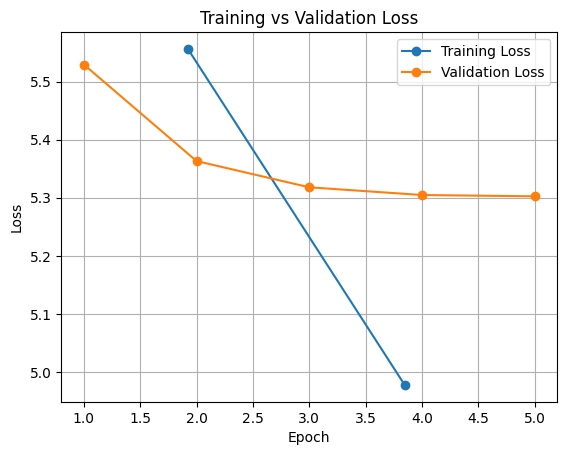

In [87]:
# plot training vs val loss
plt.figure()

plt.plot(train_epochs, train_loss, marker='o', label="Training Loss")
plt.plot(val_epochs, val_loss, marker='o', label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

### Evaluate Finetuned Model

In [88]:
# evaluate finetuned model
results = trainer_p2.evaluate()
results

{'eval_loss': 5.302476406097412,
 'eval_pos_accuracy': 0.7476954387645157,
 'eval_pos_f1_macro': 0.5889529894278954,
 'eval_pos_f1_weighted': 0.7365157872099763,
 'eval_runtime': 5.3168,
 'eval_samples_per_second': 334.414,
 'eval_steps_per_second': 10.533,
 'epoch': 5.0}

### Save Model

In [89]:
model_multi.save_pretrained("/content/drive/MyDrive/FYP/morphological_analyser_multihead")
tokenizer.save_pretrained("/content/drive/MyDrive/FYP/morphological_analyser_multihead")
model_multi.push_to_hub("amysp/latin-morphological-analyser-multihead")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...2bsfxrg/model.safetensors:  27%|##6       |  120MB /  452MB            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/amysp/latin-morphological-analyser-multihead/commit/cf095ebff2651b312e6d7ede2fccc4a38f2833ae', commit_message='Upload LatinMorphologicalAnalyser', commit_description='', oid='cf095ebff2651b312e6d7ede2fccc4a38f2833ae', pr_url=None, repo_url=RepoUrl('https://huggingface.co/amysp/latin-morphological-analyser-multihead', endpoint='https://huggingface.co', repo_type='model', repo_id='amysp/latin-morphological-analyser-multihead'), pr_revision=None, pr_num=None)